# Chemistry vs. LLM Route Scoring — Merge & Comparison

Merges the rule-based cheminformatics scores (`data/chem_scoring/routes_chem_scores.csv`) with the
LLM route-judge scores (`data/llm_scoring/routes_llm_scores.csv`) on SMILES, then compares score
distributions, pairwise correlations, and correlation with route-search time.

Neither file carries a per-row timestamp, so "time" below means `search_duration` — the AiZynthFinder
retrosynthetic search wall-clock time (seconds), carried over from `data/routes/routes.csv` — the only
time-denominated field available.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

_PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sns.set_theme(style="whitegrid")

SCORE_COLS = ["sa_score", "sc_score", "ra_score", "syba_score", "gasa_es_prob", "fs_score", "llm_score"]

## Load & merge

In [2]:
chem = pd.read_csv(_PROJECT_ROOT / "data/chem_scoring/routes_chem_scores.csv")
chem = chem.rename(columns={"molecule": "SMILES"})
llm = pd.read_csv(_PROJECT_ROOT / "data/llm_scoring/routes_llm_scores.csv")

# AiZynthFinder writes the literal string "Exceeded" instead of a duration when the search
# hits its time budget without resolving a route; coerce those to NaN so search_duration is
# usable as a numeric "time" axis.
n_before = llm["search_duration"].notna().sum()
llm["search_duration"] = pd.to_numeric(llm["search_duration"], errors="coerce")
n_exceeded = n_before - llm["search_duration"].notna().sum()

print(f"chem: {chem.shape}, unique SMILES: {chem['SMILES'].nunique()}")
print(f"llm:  {llm.shape}, unique SMILES: {llm['SMILES'].nunique()}")
print(f"search_duration: {n_exceeded} rows were the 'Exceeded' sentinel (search timed out), coerced to NaN")

chem: (4000, 12), unique SMILES: 3994
llm:  (4000, 26), unique SMILES: 3994
search_duration: 519 rows were the 'Exceeded' sentinel (search timed out), coerced to NaN


Both files carry a handful of SMILES that appear twice (re-run AiZynthFinder searches with a
different `search_duration`). Keep the first occurrence of each so the merge doesn't fan out.

In [3]:
chem_dedup = chem.drop_duplicates(subset="SMILES", keep="first")
llm_dedup = llm.drop_duplicates(subset="SMILES", keep="first")
print(f"dropped {len(chem) - len(chem_dedup)} duplicate chem rows, {len(llm) - len(llm_dedup)} duplicate llm rows")

df = pd.merge(chem_dedup, llm_dedup, on="SMILES", how="inner")
print(f"merged: {df.shape}")
df.head()

dropped 6 duplicate chem rows, 6 duplicate llm rows
merged: (3994, 37)


,SMILES,sa_score,sa_score_scaled,sc_score,sc_score_scaled,ra_score,syba_score,syba_score_scaled,gasa_pred,gasa_es_prob,...,llm_confidence,llm_n_samples,llm_risk_factors,llm_rationale,llm_n_building_blocks,llm_resolved_depth,llm_n_steps,llm_mean_step_score,llm_min_step_score,llm_step_scores
0,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,6.222741,0.419695,5.000000,3.508257e-09,0.161986,249.020919,1.0,0,0.826661,...,61.666667,3,Lack of clear and chemically feasible coupling...,Step S2 involves coupling a carboxylic acid ([...,3,2.0,2,NaN,NaN,NaN
1,COc1c(O)cc(O)c2c(=O)cc(-c3ccc(OCc4cn(CCCCCCCCC...,3.985074,0.668325,5.000000,4.185795e-09,0.186988,134.580684,1.0,0,0.946929,...,95.000000,3,Potential regioselectivity issues in S2; Handl...,The retrosynthesis is sound and utilizes readi...,4,2.0,3,NaN,NaN,NaN
2,CCS(=O)(=O)Nc1ccc(Oc2ccc(F)cc2F)c(-c2cn(C)c(=O...,4.705671,0.588259,5.000000,1.620926e-13,0.921628,181.353748,1.0,0,0.942627,...,86.666667,3,Potential chemoselectivity issues during the C...,"The route is composed of three steps, connecti...",4,3.0,3,NaN,NaN,NaN
3,O=C(COc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)NCCC...,4.047805,0.661355,5.000000,1.298772e-08,0.734383,249.438567,1.0,0,0.975695,...,96.666667,3,Availability and cost of complex building bloc...,The target molecule can be synthesized in a si...,2,2.0,1,NaN,NaN,NaN
4,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCNc3c...,4.587479,0.601391,4.999998,4.992252e-07,0.167812,95.603579,1.0,0,0.867942,...,85.000000,3,Chemoselectivity in the final coupling of I1 a...,The route is synthetically sound and utilizes ...,5,3.0,6,NaN,NaN,NaN


In [4]:
out_path = _PROJECT_ROOT / "data/processed/analysis/routes_chem_llm_scores_merged.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path, index=False)
out_path

PosixPath('/proj/berzelius-2026-62/users/x_steri/PROTAC-Synthesizability/data/processed/analysis/routes_chem_llm_scores_merged.csv')

In [6]:
df = df[df['resolved']]
df

,SMILES,sa_score,sa_score_scaled,sc_score,sc_score_scaled,ra_score,syba_score,syba_score_scaled,gasa_pred,gasa_es_prob,...,llm_confidence,llm_n_samples,llm_risk_factors,llm_rationale,llm_n_building_blocks,llm_resolved_depth,llm_n_steps,llm_mean_step_score,llm_min_step_score,llm_step_scores
0,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,6.222741,0.419695,5.000000,3.508257e-09,0.161986,249.020919,1.000000,0,0.826661,...,61.666667,3,Lack of clear and chemically feasible coupling...,Step S2 involves coupling a carboxylic acid ([...,3,2.0,2,NaN,NaN,NaN
1,COc1c(O)cc(O)c2c(=O)cc(-c3ccc(OCc4cn(CCCCCCCCC...,3.985074,0.668325,5.000000,4.185795e-09,0.186988,134.580684,1.000000,0,0.946929,...,95.000000,3,Potential regioselectivity issues in S2; Handl...,The retrosynthesis is sound and utilizes readi...,4,2.0,3,NaN,NaN,NaN
2,CCS(=O)(=O)Nc1ccc(Oc2ccc(F)cc2F)c(-c2cn(C)c(=O...,4.705671,0.588259,5.000000,1.620926e-13,0.921628,181.353748,1.000000,0,0.942627,...,86.666667,3,Potential chemoselectivity issues during the C...,"The route is composed of three steps, connecti...",4,3.0,3,NaN,NaN,NaN
3,O=C(COc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)NCCC...,4.047805,0.661355,5.000000,1.298772e-08,0.734383,249.438567,1.000000,0,0.975695,...,96.666667,3,Availability and cost of complex building bloc...,The target molecule can be synthesized in a si...,2,2.0,1,NaN,NaN,NaN
4,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCNc3c...,4.587479,0.601391,4.999998,4.992252e-07,0.167812,95.603579,1.000000,0,0.867942,...,85.000000,3,Chemoselectivity in the final coupling of I1 a...,The route is synthetically sound and utilizes ...,5,3.0,6,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3986,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCn6nc(C(=O)N...,5.973732,0.447363,5.000000,1.332268e-15,0.381967,203.590292,1.000000,0,0.900887,...,91.666667,3,Handling of potentially reactive reagents like...,The route appears chemically sound and feasibl...,11,6.0,12,NaN,NaN,NaN
3988,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,7.263444,0.304062,5.000000,6.178613e-12,0.016546,272.059804,1.000000,1,0.309396,...,81.666667,3,Potential for epimerization at the proline-lik...,"The route is well-designed, utilizing standard...",12,6.0,14,NaN,NaN,NaN
3989,Cc1ccc(C2CCCN(c3ccc(N4CCC(CN5CCN(c6ccc7c(c6)CN...,4.173805,0.647355,5.000000,9.880222e-09,0.229707,29.184907,1.000000,0,0.685065,...,90.000000,2,Ambiguity in the exact coupling conditions for...,"The route is well-designed and convergent, uti...",6,3.0,5,NaN,NaN,NaN
3991,C#Cc1c(F)ccc2cccc(-c3ncc4c(N5CC6CCC(C5)N6)nc(O...,6.629358,0.374516,5.000000,3.651641e-08,0.128313,9.633214,0.999934,1,0.075920,...,76.666667,3,Chemoselectivity issues with activated acyl ch...,"The retrosynthesis appears logical, breaking d...",14,6.0,15,NaN,NaN,NaN


In [7]:
df[SCORE_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
sa_score,3429.0,4.927455,0.916213,2.940162,4.222604,4.775887,5.386344,7.648569
sc_score,3429.0,4.986130,0.063618,4.009509,4.999955,5.000000,5.000000,5.000000
ra_score,3429.0,0.404328,0.261713,0.005022,0.175895,0.368766,0.617078,0.988268
syba_score,3429.0,113.892787,81.343148,-90.484636,55.625421,101.259823,164.823670,401.015409
gasa_es_prob,3429.0,0.686469,0.289368,0.001443,0.469458,0.787813,0.938785,0.998553
fs_score,3429.0,-30.347877,4.854164,-45.500000,-33.781250,-30.359375,-27.375000,-7.394531
llm_score,3429.0,71.042529,15.311009,23.333333,58.333333,75.000000,83.333333,100.000000


## Score distributions

Six chemistry-based scorers (SA, SCScore, RAscore, SYBA, GASA, FSscore) against the LLM route-judge
score (`llm_score`, 0-100 scale, higher = more feasible).

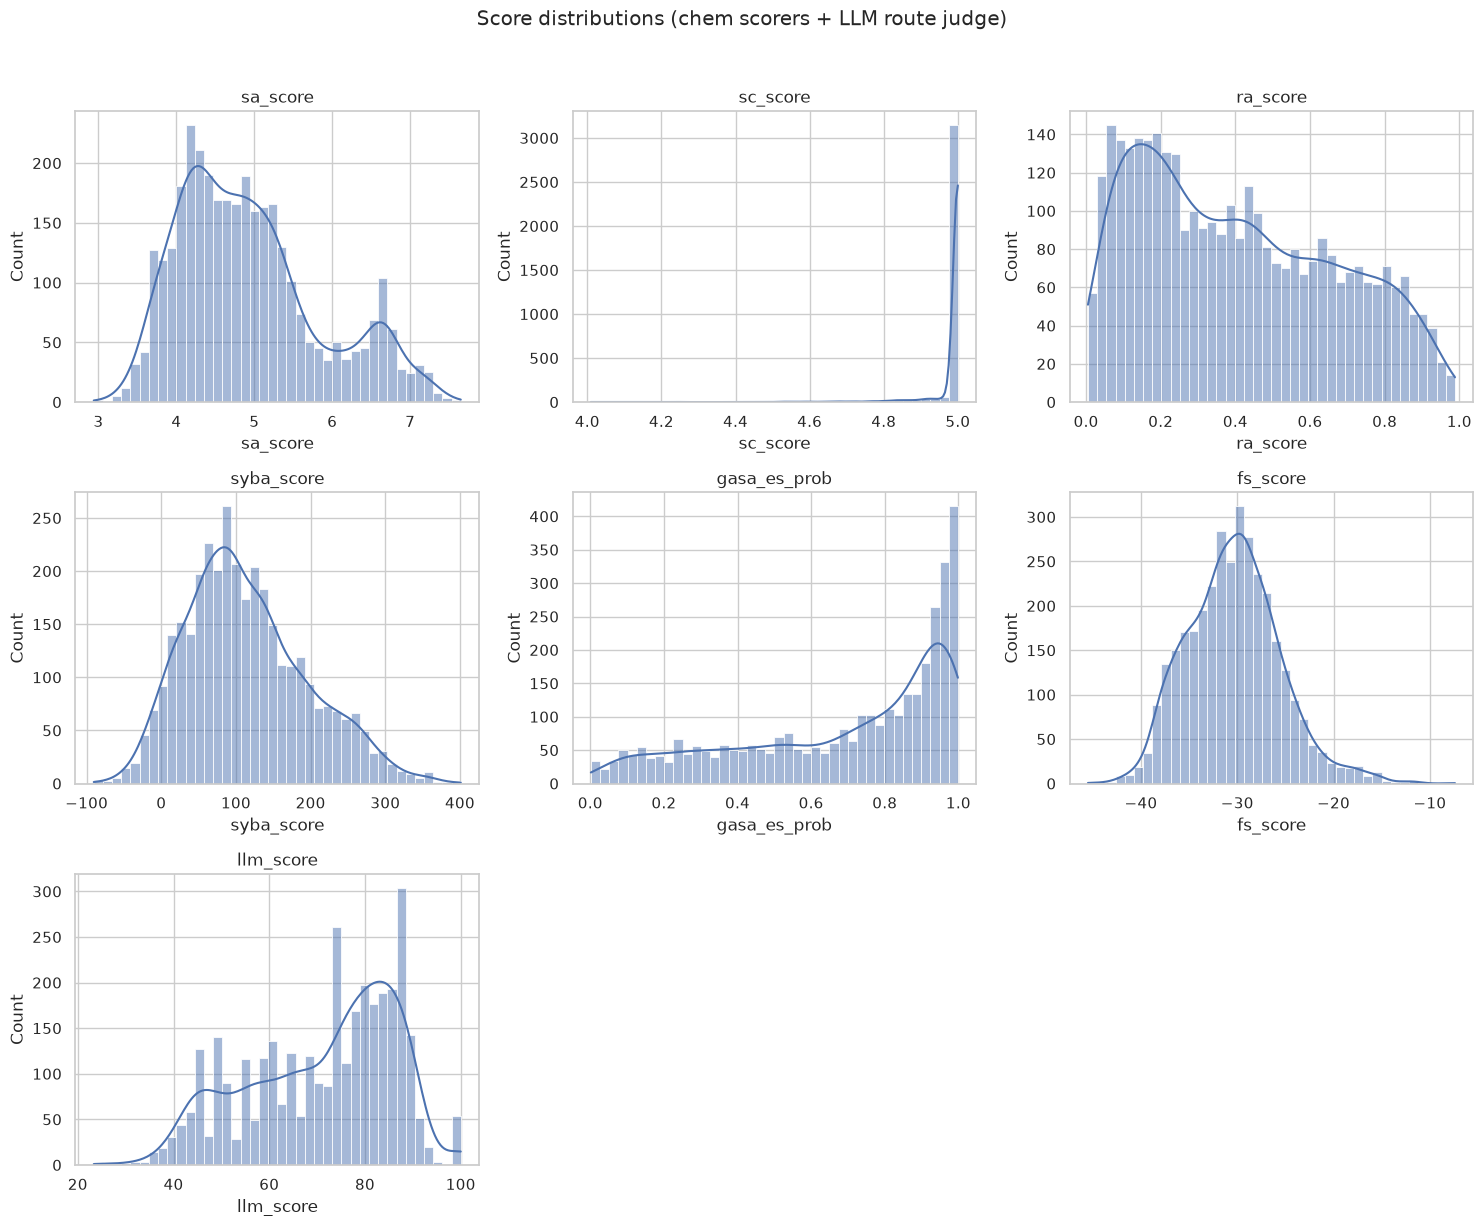

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, SCORE_COLS):
    # fixed bin count: sc_score's IQR is ~0 (saturates at 5.0 for most molecules), which makes
    # numpy's 'auto' binning pick a degenerate bin width and renders as an empty panel
    sns.histplot(df[col].dropna(), kde=True, bins=40, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(SCORE_COLS):]:
    ax.axis("off")
fig.suptitle("Score distributions (chem scorers + LLM route judge)", y=1.02)
fig.tight_layout()
plt.show()

## Correlation between scores

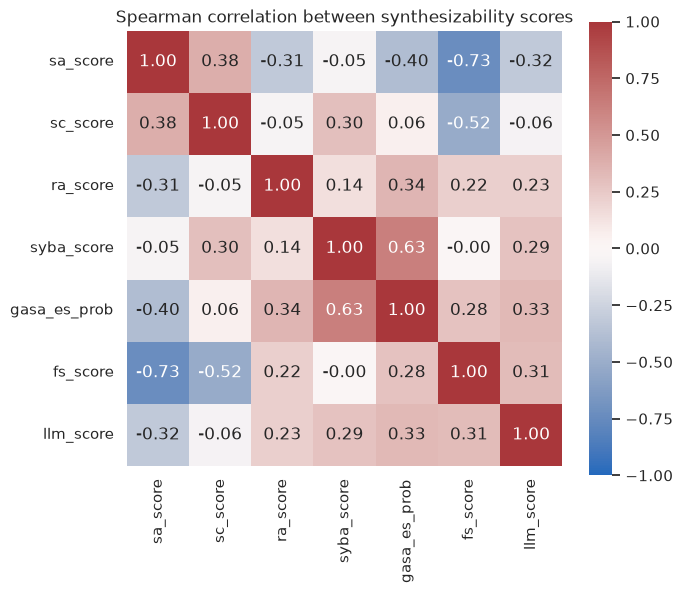

In [9]:
corr = df[SCORE_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Spearman correlation between synthesizability scores")
fig.tight_layout()
plt.show()

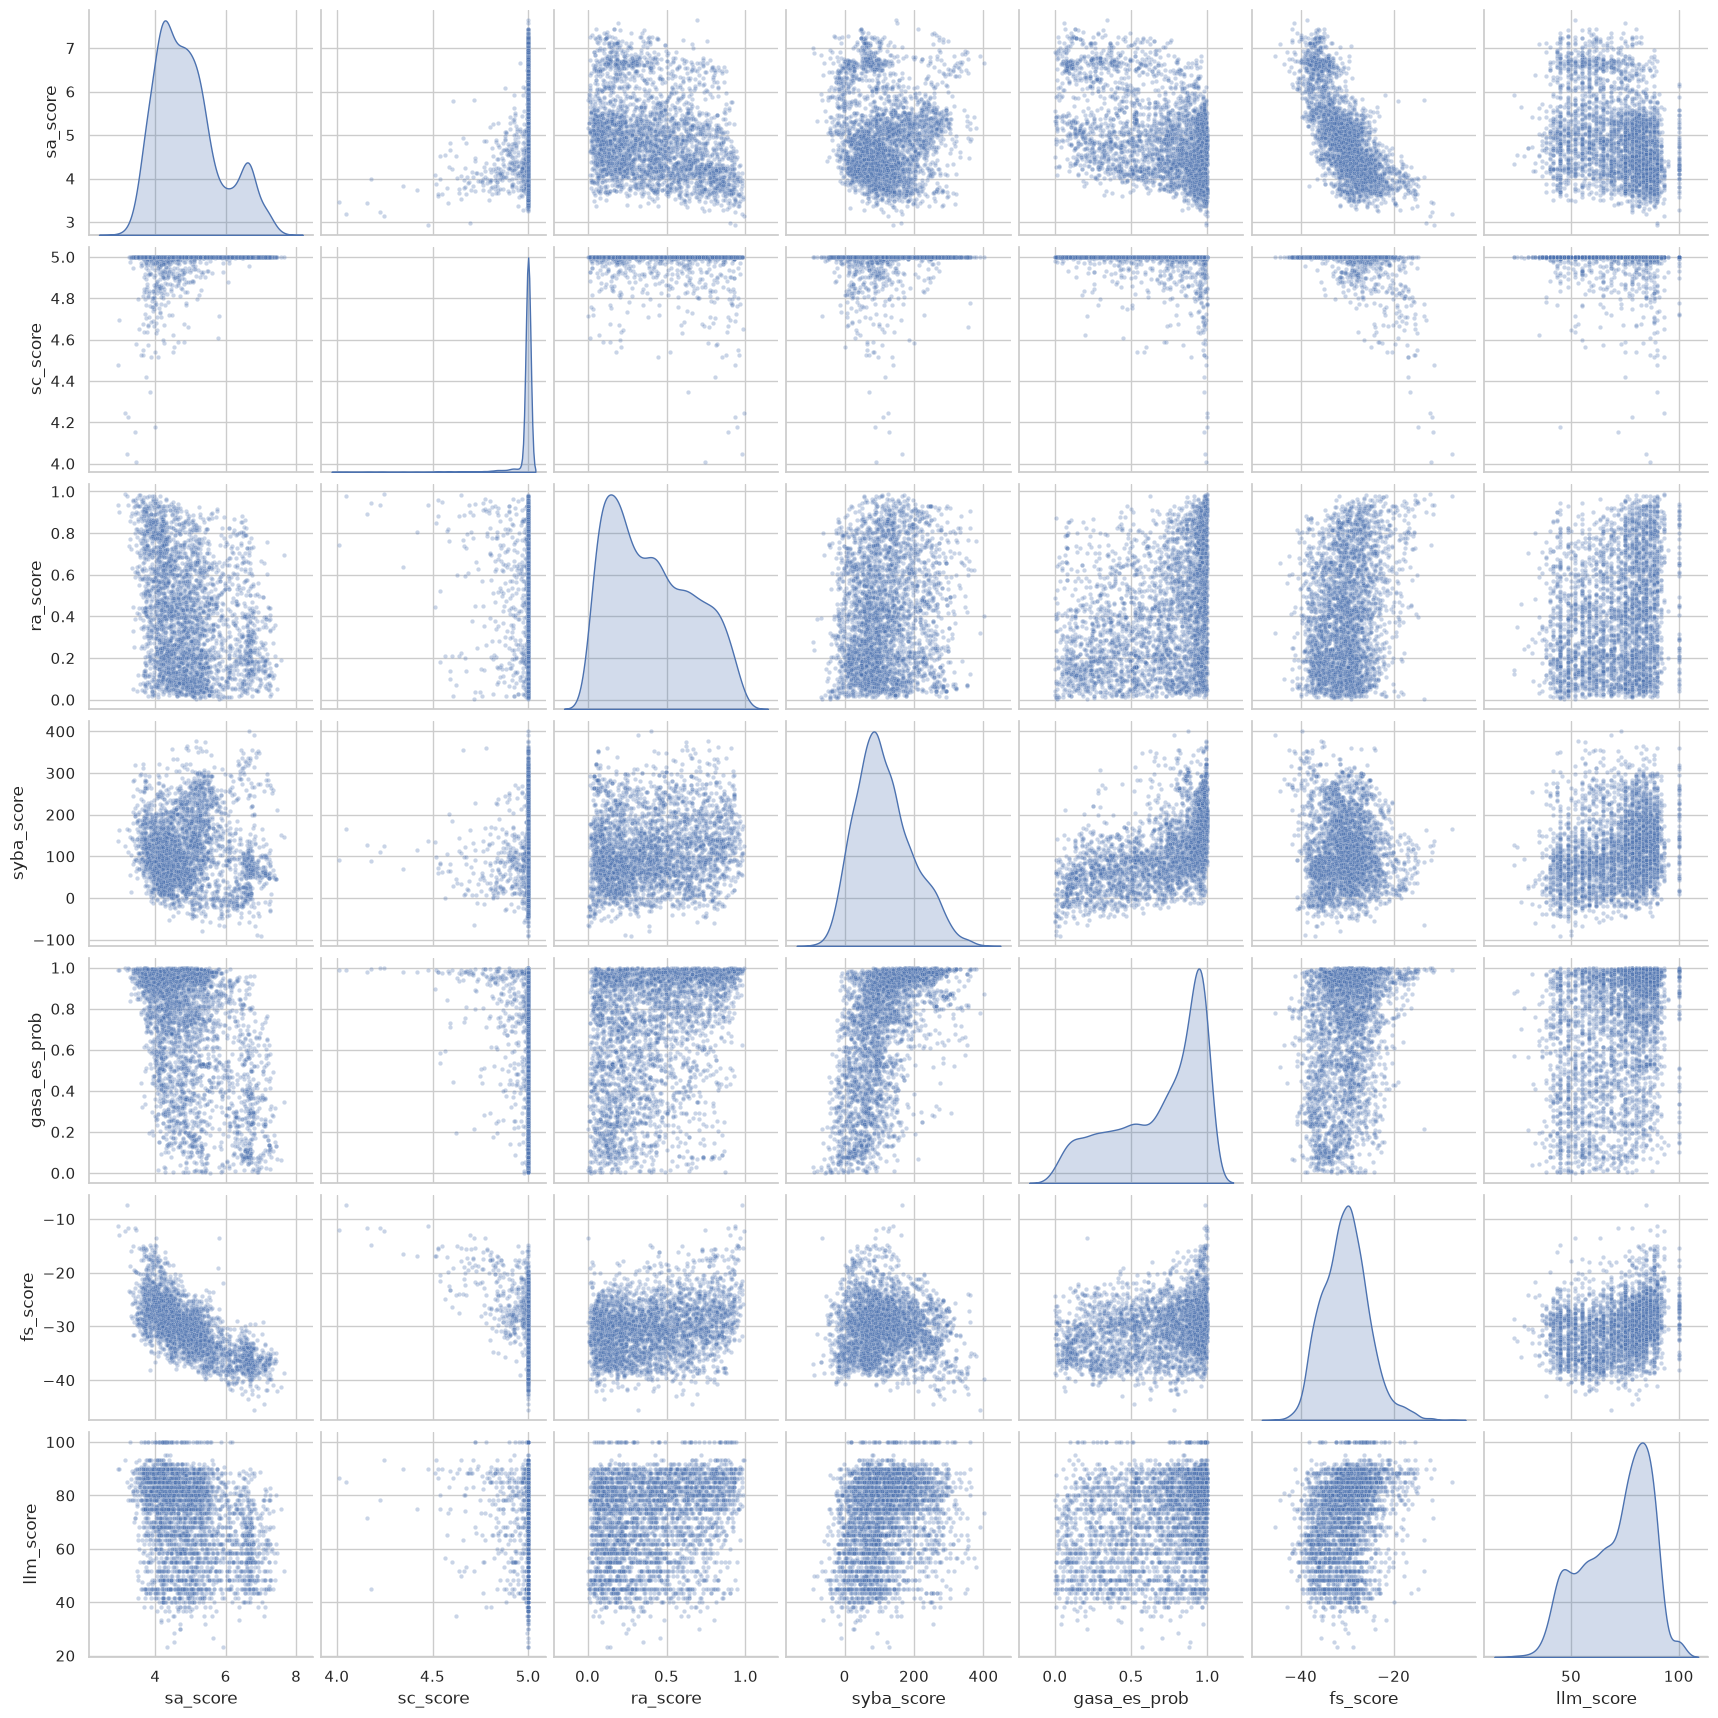

In [10]:
sns.pairplot(df[SCORE_COLS].dropna(), diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})
plt.show()

## Correlation with time (AiZynthFinder search duration)

Neither score file has a per-row timestamp; `search_duration` (seconds) is the only time-denominated
field, so it stands in for "time" below. Durations are heavily right-skewed, hence the log scale.

`search_duration` is the string `"Exceeded"` for searches that hit AiZynthFinder's time budget without
resolving (all `resolved == False`) — coerced to NaN above, so this section only covers routes that
finished within the search budget.

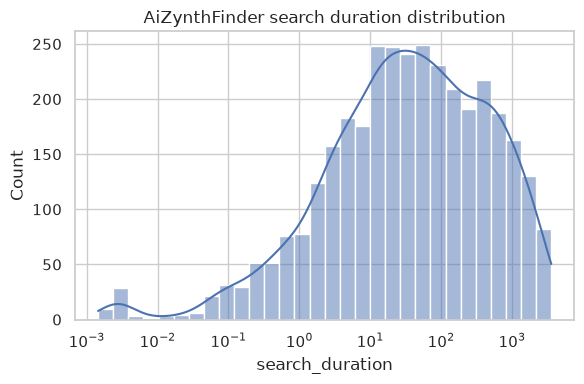

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df["search_duration"].dropna(), kde=True, ax=ax, log_scale=True)
ax.set_title("AiZynthFinder search duration distribution")
fig.tight_layout()
plt.show()

In [12]:
time_corr = df[SCORE_COLS].corrwith(df["search_duration"], method="spearman").sort_values()
time_corr

llm_score      -0.579202
fs_score       -0.503321
gasa_es_prob   -0.391032
ra_score       -0.309755
syba_score     -0.183113
sc_score        0.204414
sa_score        0.539394
dtype: float64

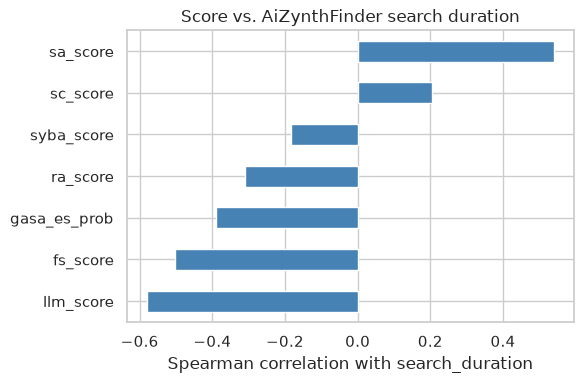

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
time_corr.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Spearman correlation with search_duration")
ax.set_title("Score vs. AiZynthFinder search duration")
fig.tight_layout()
plt.show()

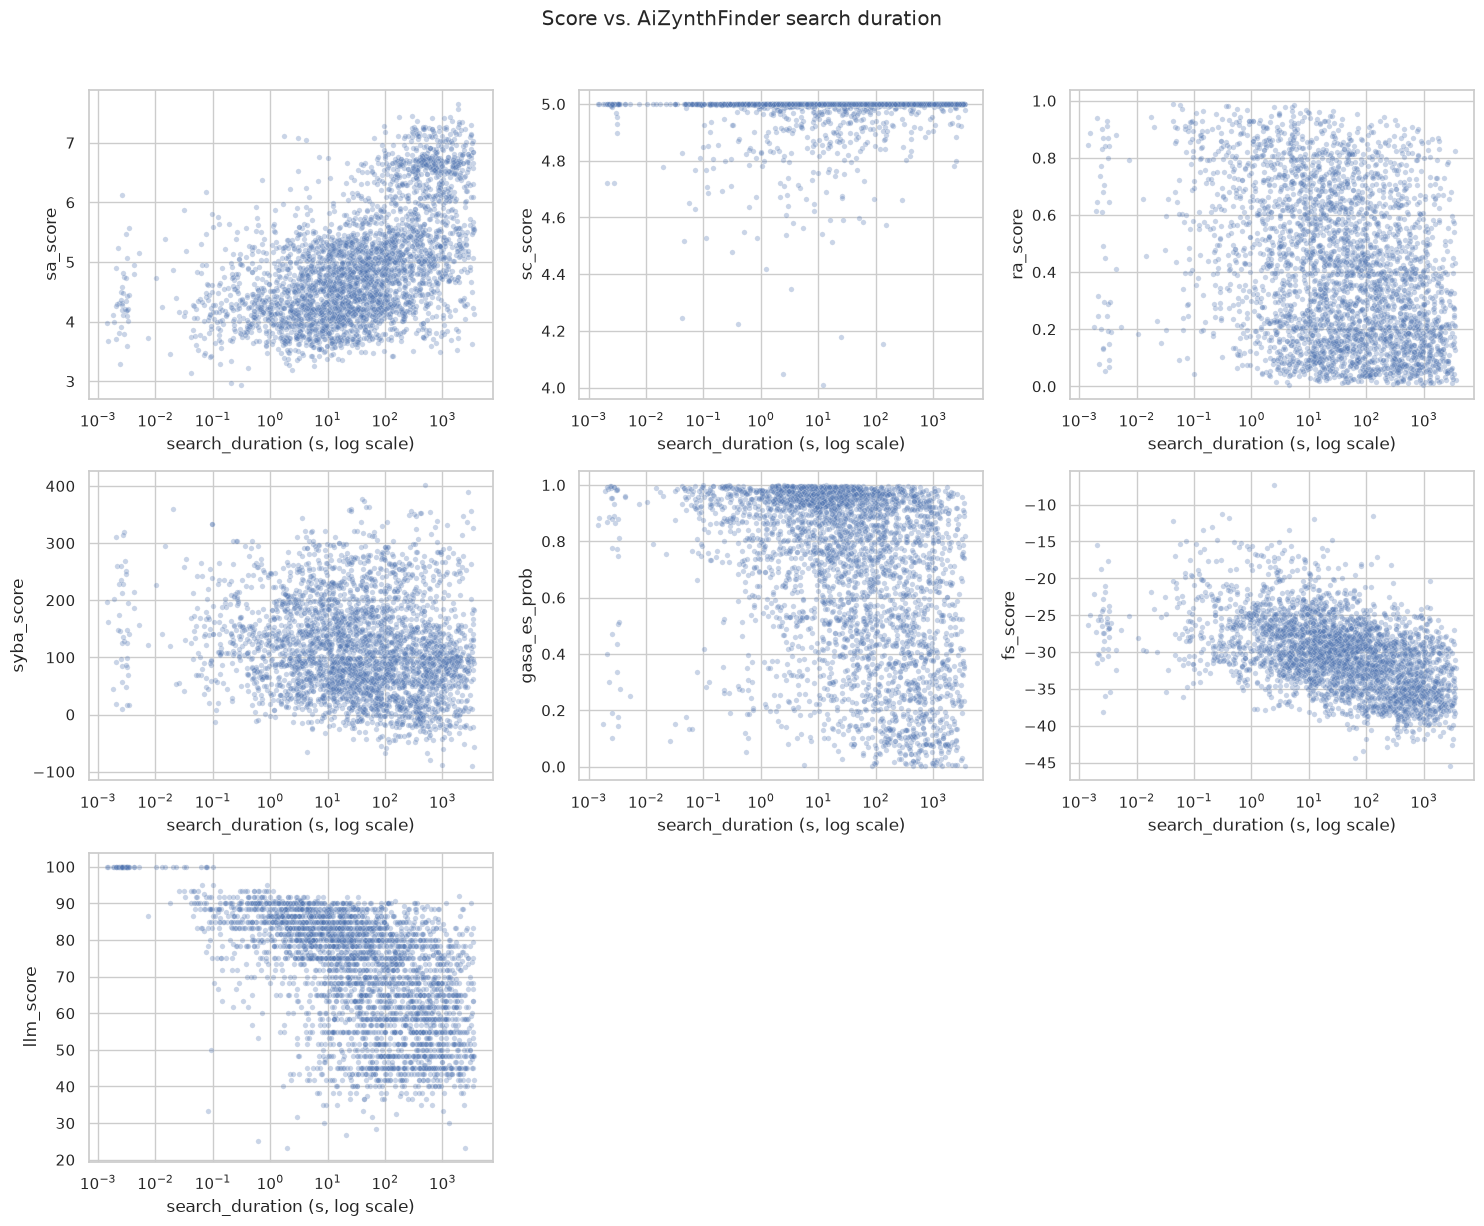

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
log_duration = df["search_duration"].clip(lower=1e-3)
for ax, col in zip(axes.flat, SCORE_COLS):
    sns.scatterplot(x=log_duration, y=df[col], ax=ax, alpha=0.3, s=15)
    ax.set_xscale("log")
    ax.set_xlabel("search_duration (s, log scale)")
    ax.set_ylabel(col)
for ax in axes.flat[len(SCORE_COLS):]:
    ax.axis("off")
fig.suptitle("Score vs. AiZynthFinder search duration", y=1.02)
fig.tight_layout()
plt.show()